# Feature Importance and Model Interpretability

After evaluating the performance of regression models, it is important to understand how individual features contribute to predictions.

Model performance metrics such as RMSE and R-squared indicate how well the model fits the data, but they do not explain the influence of each variable.

Feature importance analysis helps to:

- Identify the most influential predictors
- Understand the direction of relationships
- Provide insights for decision-making
- Improve model transparency

In linear regression, feature importance is derived from model coefficients.

## Import Required Libraries

The following packages are used in this workflow:

- `tidyverse`: A collection of essential packages (including `dplyr`, `ggplot2`, and `readr`) for data science.
- `broom`: To tidy model results into structured data frames.
- `caret`: To facilitate machine learning tasks, such as data partitioning.


In [8]:
# ==============================================================================
# Load Required Libraries
# ==============================================================================

# Data manipulation and cleaning
library(dplyr)

# Data visualization
library(ggplot2)

# Data import and file reading
library(readr)

# Statistical modeling (tidying model outputs)
library(broom)

# Machine learning and data partitioning
library(caret)

# Note: tidyverse is loaded here to ensure all related dependencies are present
library(tidyverse)


## Load Dataset and Train Model

We train the refined regression model used in previous steps.

In [3]:
# Load dataset
bike_data <- read_csv("clean_bike_data.csv")

# Split data
set.seed(123)
train_index <- createDataPartition(bike_data$rented_bike_count, p = 0.8, list = FALSE)

train_data <- bike_data[train_index, ]
test_data <- bike_data[-train_index, ]

# Add engineered features
train_data <- train_data %>%
  mutate(
    temperature_sq = temperature^2,
    humidity_sq = humidity^2,
    temp_humidity = temperature * humidity
  )

# Train refined model
model <- lm(
  rented_bike_count ~ temperature + humidity + wind_speed +
    temperature_sq + humidity_sq + temp_humidity,
  data = train_data
)

Rows: 8465 Columns: 17── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (4): seasons, holiday, functioning_day, day_of_week
dbl  (12): rented_bike_count, hour, temperature, humidity, wind_speed, visib...
date  (1): date
ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

## Extract Model Coefficients

We extract coefficients from the model to analyze feature importance.

In [4]:
# Convert model output into tidy format

model_summary <- tidy(model)

# Display coefficients
model_summary

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-103.0298116,47.30070276,-2.178188,2.942647e-02
temperature,53.6135167,1.64560852,32.579751,2.067765e-216
humidity,22.3211299,1.53455241,14.545694,3.191857e-47
wind_speed,51.9972093,5.97165564,8.707336,3.862360e-18
temperature_sq,-0.4481891,0.03980413,-11.259865,3.757291e-29
humidity_sq,-0.2454900,0.01295285,-18.952588,4.310814e-78
temp_humidity,-0.2119388,0.02741183,-7.731655,1.215756e-14


## Feature Importance Based on Magnitude

The absolute value of coefficients indicates the strength of influence.

Higher magnitude → stronger impact on predictions.

In [5]:
# Calculate absolute coefficient values

feature_importance <- model_summary %>%
  filter(term != "(Intercept)") %>%
  mutate(abs_coef = abs(estimate)) %>%
  arrange(desc(abs_coef))

# Display ranked features
feature_importance

term,estimate,std.error,statistic,p.value,abs_coef
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
temperature,53.6135167,1.64560852,32.579751,2.067765e-216,53.6135167
wind_speed,51.9972093,5.97165564,8.707336,3.862360e-18,51.9972093
humidity,22.3211299,1.53455241,14.545694,3.191857e-47,22.3211299
temperature_sq,-0.4481891,0.03980413,-11.259865,3.757291e-29,0.4481891
humidity_sq,-0.2454900,0.01295285,-18.952588,4.310814e-78,0.2454900
temp_humidity,-0.2119388,0.02741183,-7.731655,1.215756e-14,0.2119388


## Visualize Feature Importance (Magnitude)

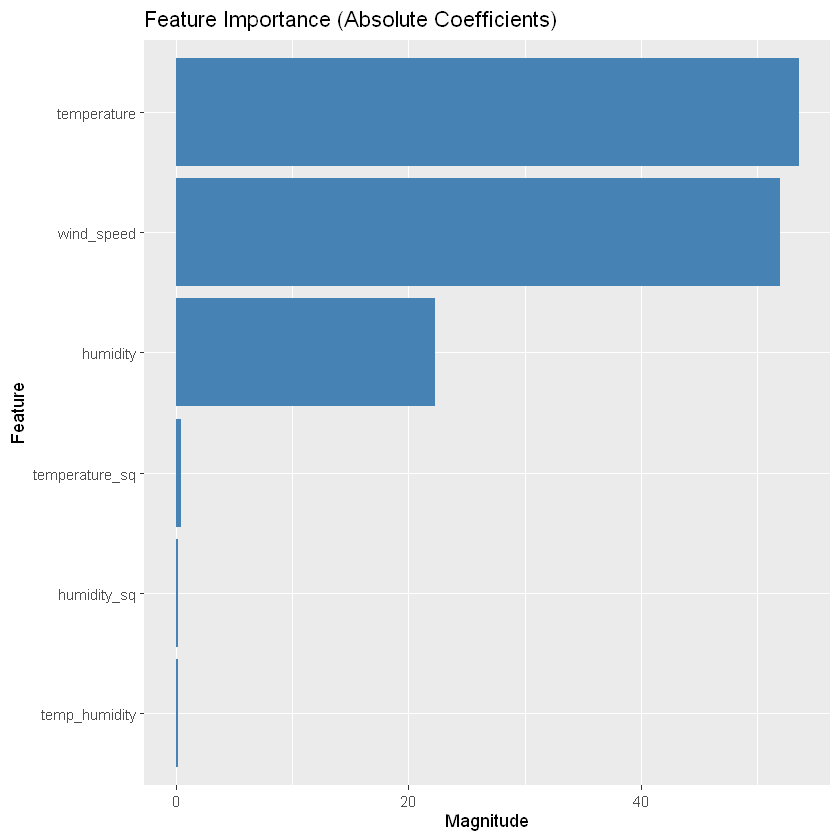

In [6]:
# Plot feature importance based on magnitude

ggplot(feature_importance, aes(x = reorder(term, abs_coef), y = abs_coef)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Feature Importance (Absolute Coefficients)",
    x = "Feature",
    y = "Magnitude"
  )

## Feature Influence Direction

The sign of the coefficient indicates:

- Positive → increases bike demand
- Negative → decreases bike demand

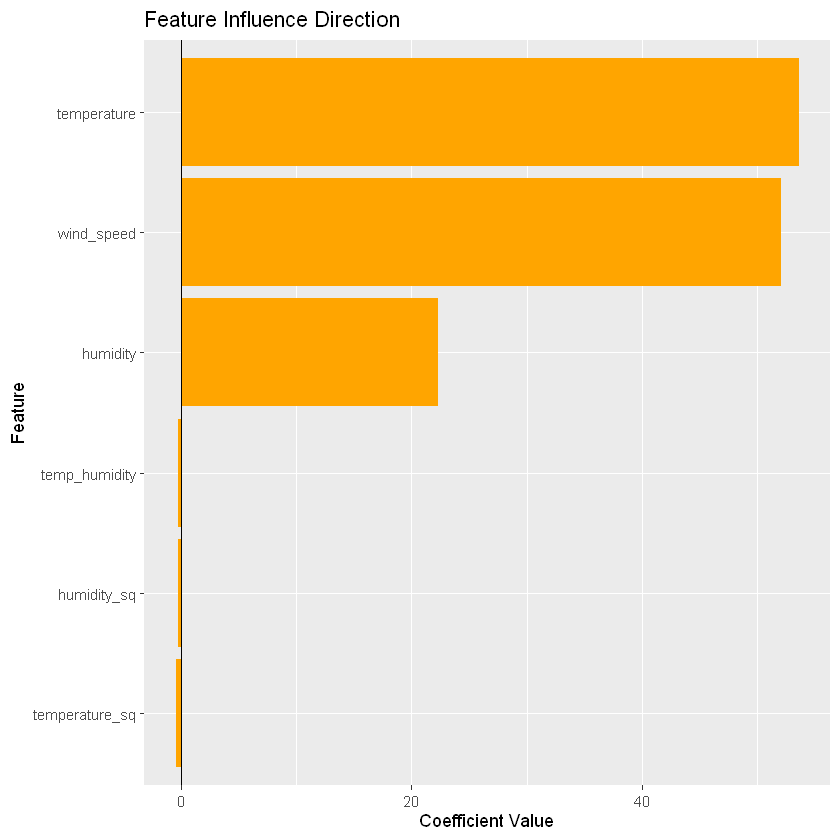

In [7]:
# Plot coefficients with direction

ggplot(feature_importance, aes(x = reorder(term, estimate), y = estimate)) +
  geom_bar(stat = "identity", fill = "orange") +
  coord_flip() +
  geom_hline(yintercept = 0, color = "black") +
  labs(
    title = "Feature Influence Direction",
    x = "Feature",
    y = "Coefficient Value"
  )

## Interpretation of Results

From the feature importance analysis:

- Features with large positive coefficients strongly increase bike demand
- Features with large negative coefficients reduce demand
- Polynomial terms capture non-linear effects
- Interaction terms reveal combined influence of variables

Weather-related features such as temperature typically have strong influence, while humidity may negatively affect demand.

Understanding these relationships helps improve model design and supports business decision-making.

---

## Author & Acknowledgment

**Author:**  
<span style="color:blue">Deepan Mehta </span>  

**GitHub Profile:**  
https://github.com/deepan-mehta-analytics

This notebook focuses on interpreting regression models by analyzing feature importance using model coefficients and visualization techniques.

The workflow follows <span style="color:blue">IBM Skills Network </span> instructional labs on model interpretation and feature importance analysis.

Special acknowledgment is given to:

- <span style="color:blue">Yan Luo </span>  
- <span style="color:blue">Jeff Grossman</span>  

---

## Project Context

This notebook represents the model interpretability stage in the end-to-end data science pipeline:

- Data Collection  
- Data Wrangling (ETL)  
- Exploratory Data Analysis (EDA)  
- Baseline Model Development  
- Model Refinement  
- Model Evaluation & Diagnostics  
- **Feature Importance Analysis**  
- Deployment (R Shiny Dashboard)

---

## Notes

Feature importance analysis enhances transparency by explaining how individual variables influence model predictions.

---